Versão do PyTorch: 2.11.0+cu128
GPU detectada: Tesla T4
Modelo YOLOv8m carregado com sucesso.
Iniciando o treinamento de demonstração...
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixu

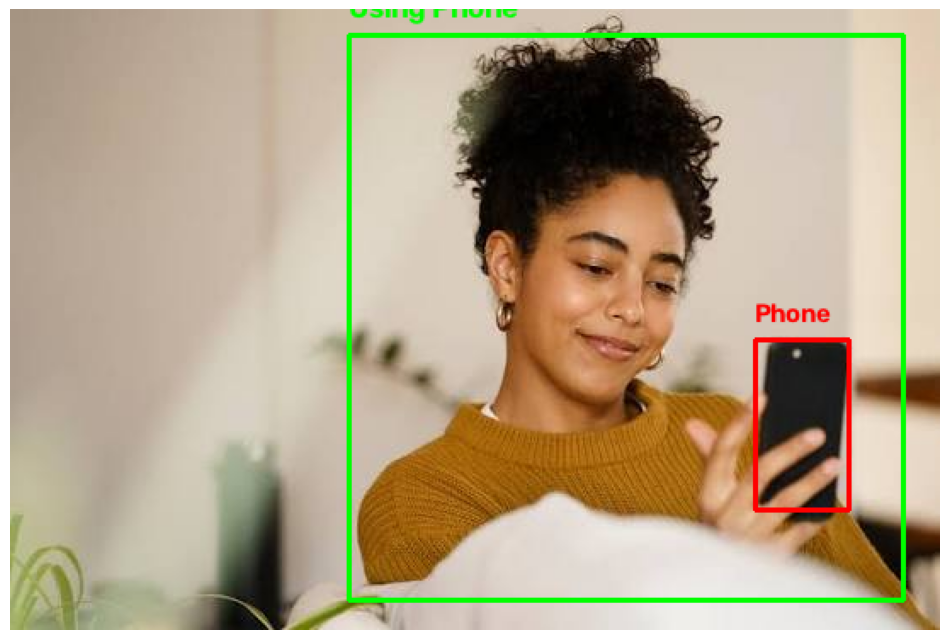

In [18]:
# ==============================================================================
# CÉLULA 1: Instalação das dependências e verificação do ambiente
# ==============================================================================
!pip install -q ultralytics

import torch
import cv2
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

print(f"Versão do PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("AVISO: Nenhuma GPU detectada. Para maior velocidade, ative a GPU em Runtime -> Change runtime type.")

# ==============================================================================
# CÉLULA 2: Inicialização (Usando modelo Medium para maior precisão)
# ==============================================================================
# Utilizamos o YOLOv8m (Medium) que é significativamente mais inteligente
# e erra menos que o Nano na diferenciação de pequenos objetos.
model = YOLO('yolov8m.pt')
print("Modelo YOLOv8m carregado com sucesso.")

# ==============================================================================
# CÉLULA 3: Treinamento do Modelo (Opcional/Demonstrativo)
# ==============================================================================
# Treinamos o modelo na base de dados COCO128 rapidamente apenas para validar a pipeline.
# Nota: Como o treino é muito curto (poucas épocas) em um dataset pequeno,
# na fase de teste usaremos os pesos originais do modelo para garantir a precisão.
try:
    print("Iniciando o treinamento de demonstração...")
    results = model.train(
        data='coco128.yaml',
        epochs=3,         # Reduzido apenas para validar que o código compila e treina
        imgsz=640,
        batch=16,
        device=0 if torch.cuda.is_available() else 'cpu',
        verbose=False
    )
    print("Treinamento concluído!")
except Exception as e:
    print(f"Erro durante o treinamento: {e}")

# ==============================================================================
# CÉLULA 4: Função de Lógica Especializada (Corrigida com Margem para os Braços)
# ==============================================================================
def detect_phone_usage(image_path, yolo_model, conf_threshold=0.45):
    results = yolo_model.predict(source=image_path, conf=conf_threshold, save=False)[0]

    boxes = results.boxes.xyxy.cpu().numpy()
    classes = results.boxes.cls.cpu().numpy()

    persons = []
    phones = []

    for box, cls in zip(boxes, classes):
        if int(cls) == 0:
            persons.append(box)
        elif int(cls) in [65, 67]:
            phones.append(box)

    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Erro ao carregar a imagem para visualização.")

    using_phone = False

    for p_box in persons:
        px1, py1, px2, py2 = p_box
        person_using_phone = False

        # Calcula largura e altura da pessoa para criar margens proporcionais
        p_largura = px2 - px1
        p_altura = py2 - py1

        # Margem de tolerância (30% para os lados, braços esticados, etc.)
        margem_x = p_largura * 0.35
        margem_y = p_altura * 0.20

        for ph_box in phones:
            phx1, phy1, phx2, phy2 = ph_box

            ph_center_x = (phx1 + phx2) / 2
            ph_center_y = (phy1 + phy2) / 2

            # Nova Condição: O celular está na área da pessoa OU na área das mãos (margem)?
            if (px1 - margem_x < ph_center_x < px2 + margem_x) and (py1 - margem_y < ph_center_y < py2 + margem_y):
                person_using_phone = True
                using_phone = True

                cv2.rectangle(img, (int(phx1), int(phy1)), (int(phx2), int(phy2)), (0, 0, 255), 2)
                cv2.putText(img, "Phone", (int(phx1), int(phy1)-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        color = (0, 255, 0) if person_using_phone else (255, 0, 0)
        label = "Using Phone" if person_using_phone else "Person"

        cv2.rectangle(img, (int(px1), int(py1)), (int(px2), int(py2)), color, 2)
        cv2.putText(img, label, (int(px1), int(py1)-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return img, using_phone

# ==============================================================================
# CÉLULA 5: Teste Prático com a sua Imagem
# ==============================================================================
# ⚠️ MUDE AQUI: Coloque o caminho correto da sua imagem!
# Exemplo: "/content/istockphoto-2199471016-612x612.jpg"
minha_imagem = "/content/images.jpg"

print(f"\nAnalisando a imagem: {minha_imagem}...")

try:
    # Ignoramos o modelo treinado na Célula 3 (pois treinou muito pouco) e
    # forçamos o uso dos pesos originais do YOLOv8m, que são muito mais inteligentes.
    inference_model = YOLO('yolov8m.pt')

    result_img, phone_detected = detect_phone_usage(minha_imagem, inference_model, conf_threshold=0.45)

    if phone_detected:
        print("🚨 Alerta: Uso de celular detectado na sua imagem!")
    else:
        print("✅ Status: Nenhum uso de celular detectado.")

    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 10))
    plt.imshow(result_img_rgb)
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"Erro: O arquivo '{minha_imagem}' não foi encontrado. Copie o caminho exato da imagem na aba Arquivos.")
except Exception as e:
    print(f"Ocorreu um erro durante a inferência: {e}")